# MultiBanFakeDetect: BanglaBERT + EfficientNet-**B4** — Early Fusion

**Paper Reference:** Faria et al. (2025) — *MultiBanFakeDetect: Integrating advanced fusion techniques for multimodal detection of Bangla fake news*

**Changes from B3 notebook:**
- Image model upgraded: `efficientnet_b3` → **`efficientnet_b4`** (1 792-d features, 380×380 native resolution)
- Batch size reduced to 6 (B4 is heavier; prevents OOM on 15 GB VRAM)
- Augmentation strengthened: added `RandomRotation`, `RandomGrayscale`, `GaussianBlur` — helps B4 generalise
- Larger classifier head: FC(1024) → FC(512) stays, but LayerNorm + GELU replaces bare ReLU (better training stability)
- Warmup cosine scheduler replaces plain CosineAnnealingLR
- Label smoothing (0.1) added to CrossEntropyLoss
- All libraries pinned to **latest stable versions** (May 2025)
- Dataset paths corrected to match actual folder names: `Train/`, `Test/`, `Validation/` and `Train.csv`, `Test.csv`, `Validation.csv`

---
### ✅ Disconnect-safe Design
- Checkpoints saved after every epoch to Drive
- Training auto-resumes from last saved checkpoint
- Final model + tokenizer saved to Drive for later inference


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

# Existing Drive folder path
DRIVE_BASE = '/content/drive/MyDrive/MultiBanFake_BanglaBERT_EfficientNetB4'

# Make sure the folder already exists
if not os.path.exists(DRIVE_BASE):
    raise FileNotFoundError(
        f"Folder not found: {DRIVE_BASE}\n"
        "Make sure you mounted the correct Google Drive account "
        "or shared the folder properly."
    )

CHECKPOINT_DIR = os.path.join(DRIVE_BASE, 'checkpoints')
MODEL_DIR      = os.path.join(DRIVE_BASE, 'saved_model')
LOG_DIR        = os.path.join(DRIVE_BASE, 'logs')

# Do NOT create new folders automatically
for d in [CHECKPOINT_DIR, MODEL_DIR, LOG_DIR]:
    if not os.path.exists(d):
        raise FileNotFoundError(f"Missing folder: {d}")

print('Using existing Drive folders:')
print('  Checkpoints :', CHECKPOINT_DIR)
print('  Saved model :', MODEL_DIR)
print('  Logs        :', LOG_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using existing Drive folders:
  Checkpoints : /content/drive/MyDrive/MultiBanFake_BanglaBERT_EfficientNetB4/checkpoints
  Saved model : /content/drive/MyDrive/MultiBanFake_BanglaBERT_EfficientNetB4/saved_model
  Logs        : /content/drive/MyDrive/MultiBanFake_BanglaBERT_EfficientNetB4/logs


## STEP 1 — Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

# ─── Edit this path if you want a different folder ───
DRIVE_BASE = '/content/drive/MyDrive/MultiBanFake_BanglaBERT_EfficientNetB4'
os.makedirs(DRIVE_BASE, exist_ok=True)

CHECKPOINT_DIR = os.path.join(DRIVE_BASE, 'checkpoints')
MODEL_DIR      = os.path.join(DRIVE_BASE, 'saved_model')
LOG_DIR        = os.path.join(DRIVE_BASE, 'logs')

for d in [CHECKPOINT_DIR, MODEL_DIR, LOG_DIR]:
    os.makedirs(d, exist_ok=True)

print('Drive mounted. Folders ready:')
print('  Checkpoints :', CHECKPOINT_DIR)
print('  Saved model :', MODEL_DIR)
print('  Logs        :', LOG_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted. Folders ready:
  Checkpoints : /content/drive/MyDrive/MultiBanFake_BanglaBERT_EfficientNetB4/checkpoints
  Saved model : /content/drive/MyDrive/MultiBanFake_BanglaBERT_EfficientNetB4/saved_model
  Logs        : /content/drive/MyDrive/MultiBanFake_BanglaBERT_EfficientNetB4/logs


## STEP 2 — Install Latest Dependencies

In [ ]:
# Latest stable versions as of May 2025
# transformers ≥4.41  timm ≥1.0  torch ≥2.3  torchvision ≥0.18
!pip install -q --upgrade \
    transformers \
    timm \
    torch torchvision \
    scikit-learn \
    seaborn \
    tqdm \
    Pillow \
    numpy \
    pandas \
    matplotlib

# Verify key versions
import importlib, subprocess
for pkg in ['torch', 'torchvision', 'transformers', 'timm', 'sklearn', 'PIL']:
    try:
        m = importlib.import_module(pkg if pkg != 'sklearn' else 'sklearn')
        v = getattr(m, '__version__', 'unknown')
        print(f'  {pkg:15s} {v}')
    except ImportError:
        print(f'  {pkg:15s} NOT FOUND')
print('Installation complete.')


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 7.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 94.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 90.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 532.3/532.3 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.2/366.2 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.0/206.0 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.5/201.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 127.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9

AttributeError: module 'numpy._core._multiarray_umath' has no attribute '_blas_supports_fpe'

In [ ]:
!pip uninstall -y pillow torchvision
!pip install pillow==10.2.0 torchvision==0.18.1

Found existing installation: pillow 12.2.0
Uninstalling pillow-12.2.0:
  Successfully uninstalled pillow-12.2.0
Found existing installation: torchvision 0.27.0
Uninstalling torchvision-0.27.0:
  Successfully uninstalled torchvision-0.27.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 779.1/779.1 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 97.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 56.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 761.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56

## STEP 3 — Import Libraries

In [ ]:
import os, json, time, shutil, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

import timm                                      # EfficientNet-B4
from transformers import AutoTokenizer, AutoModel

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

# ─── Device ───
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'GPU           : {torch.cuda.get_device_name(0)}')
    print(f'VRAM          : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
print(f'PyTorch       : {torch.__version__}')
print(f'timm          : {timm.__version__}')


Using device: cuda
GPU           : Tesla T4
VRAM          : 15.6 GB
PyTorch       : 2.3.1+cu121
timm          : 1.0.7


## STEP 4 — Dataset Paths

Your Drive structure must look like:
```
MyDrive/
    dataset/
        Train.csv
        Test.csv
        Validation.csv
        Train/       ← image files
        Test/
        Validation/
```


In [ ]:
# ─── Dataset paths — edit DATASET_BASE if your folder is elsewhere ───
DATASET_BASE = '/content/drive/MyDrive/dataset'

CSV_PATHS = {
    'train'      : os.path.join(DATASET_BASE, 'Train.csv'),
    'test'       : os.path.join(DATASET_BASE, 'Test.csv'),
    'validation' : os.path.join(DATASET_BASE, 'Validation.csv'),
}

IMAGE_DIRS = {
    'train'      : os.path.join(DATASET_BASE, 'Train'),
    'test'       : os.path.join(DATASET_BASE, 'Test'),
    'validation' : os.path.join(DATASET_BASE, 'Validation'),
}

# Verify files exist
all_ok = True
for split, path in CSV_PATHS.items():
    exists = os.path.exists(path)
    flag   = '✅' if exists else '❌ NOT FOUND'
    if not exists:
        all_ok = False
    print(f'  {split} CSV  → {flag} | {path}')

for split, path in IMAGE_DIRS.items():
    exists = os.path.isdir(path)
    flag   = '✅' if exists else '❌ NOT FOUND'
    if not exists:
        all_ok = False
    print(f'  {split} imgs → {flag} | {path}')

if not all_ok:
    print('\n⚠️  Fix the missing paths above before continuing.')
else:
    print('\n✅ All paths verified.')


  train CSV  → ✅ | /content/drive/MyDrive/dataset/Train.csv
  test CSV  → ✅ | /content/drive/MyDrive/dataset/Test.csv
  validation CSV  → ✅ | /content/drive/MyDrive/dataset/Validation.csv
  train imgs → ✅ | /content/drive/MyDrive/dataset/Train
  test imgs → ✅ | /content/drive/MyDrive/dataset/Test
  validation imgs → ✅ | /content/drive/MyDrive/dataset/Validation

✅ All paths verified.


## STEP 5 — Data Loading & Preprocessing

In [ ]:
def load_and_match(csv_path, image_dir):
    """Load CSV and attach full image paths (extension-agnostic)."""
    df = pd.read_csv(csv_path)

    # Build image_id → full_path map
    image_map = {}
    if os.path.isdir(image_dir):
        for fname in os.listdir(image_dir):
            name_no_ext = os.path.splitext(fname)[0]
            image_map[name_no_ext] = os.path.join(image_dir, fname)

    df['image_path'] = df['image_id'].astype(str).map(image_map)

    before = len(df)
    df = df.dropna(subset=['image_path', 'description', 'label'])
    df = df[df['image_path'].apply(os.path.exists)]
    print(f'  Loaded {len(df)}/{before} rows (dropped {before - len(df)} missing/invalid)')

    df['label'] = df['label'].astype(int)
    return df.reset_index(drop=True)


print('Loading datasets...')
train_df = load_and_match(CSV_PATHS['train'],      IMAGE_DIRS['train'])
val_df   = load_and_match(CSV_PATHS['validation'], IMAGE_DIRS['validation'])
test_df  = load_and_match(CSV_PATHS['test'],       IMAGE_DIRS['test'])

print(f'\nTrain   : {len(train_df)} samples')
print(f'Val     : {len(val_df)} samples')
print(f'Test    : {len(test_df)} samples')
print(f'\nLabel distribution (train):')
print(train_df['label'].value_counts())


Loading datasets...
  Loaded 7680/7680 rows (dropped 0 missing/invalid)
  Loaded 960/960 rows (dropped 0 missing/invalid)
  Loaded 960/960 rows (dropped 0 missing/invalid)

Train   : 7680 samples
Val     : 960 samples
Test    : 960 samples

Label distribution (train):
label
0    3840
1    3840
Name: count, dtype: int64


## STEP 6 — Configuration (Hyperparameters)

In [ ]:
import os
import json

# Base project directory
BASE_DIR = "/content/drive/MyDrive/MultiBanFake_BanglaBERT_EfficientNetB4"

# Create subdirectories
CHECKPOINT_DIR = os.path.join(BASE_DIR, "checkpoints")
MODEL_DIR      = os.path.join(BASE_DIR, "models")
LOG_DIR        = os.path.join(BASE_DIR, "logs")

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

# ──────────────────────────────────────────────────────────
#  Configuration
# ──────────────────────────────────────────────────────────
CFG = {
    # Model names
    'text_model_name'  : 'csebuetnlp/banglabert',
    'image_model_name' : 'efficientnet_b4',

    # Text
    'max_seq_length' : 128,

    # Image
    'img_size'       : 380,

    # Training
    'batch_size'     : 6,
    'num_epochs'     : 35,
    'learning_rate'  : 2e-4,
    'weight_decay'   : 1e-2,
    'num_classes'    : 2,

    # Regularisation
    'dropout'           : 0.4,
    'label_smoothing'   : 0.1,
    'warmup_epochs'     : 3,

    # Paths
    'checkpoint_dir' : CHECKPOINT_DIR,
    'model_dir'      : MODEL_DIR,
    'log_dir'        : LOG_DIR,
}

# Save config
with open(os.path.join(LOG_DIR, 'config.json'), 'w') as f:
    json.dump(CFG, f, indent=2)

print('Configuration:')
for k, v in CFG.items():
    print(f'  {k:22s}: {v}')

Configuration:
  text_model_name       : csebuetnlp/banglabert
  image_model_name      : efficientnet_b4
  max_seq_length        : 128
  img_size              : 380
  batch_size            : 6
  num_epochs            : 35
  learning_rate         : 0.0002
  weight_decay          : 0.01
  num_classes           : 2
  dropout               : 0.4
  label_smoothing       : 0.1
  warmup_epochs         : 3
  checkpoint_dir        : /content/drive/MyDrive/MultiBanFake_BanglaBERT_EfficientNetB4/checkpoints
  model_dir             : /content/drive/MyDrive/MultiBanFake_BanglaBERT_EfficientNetB4/models
  log_dir               : /content/drive/MyDrive/MultiBanFake_BanglaBERT_EfficientNetB4/logs


## STEP 7 — Tokenizer & Image Transforms

In [ ]:
# ─── BanglaBERT Tokenizer ───
print('Loading BanglaBERT tokenizer...')
tokenizer = AutoTokenizer.from_pretrained(CFG['text_model_name'])
print('Tokenizer loaded:', tokenizer.__class__.__name__)

# ─── Image Transforms ───────────────────────────────────────────────
# EfficientNet-B4 → 380×380, ImageNet normalisation
# B4 benefits from stronger augmentation than B3 (more capacity to utilise it)
IMG_MEAN = [0.485, 0.456, 0.406]
IMG_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((CFG['img_size'] + 20, CFG['img_size'] + 20)),  # slightly larger then crop
    transforms.RandomCrop(CFG['img_size']),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomGrayscale(p=0.05),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMG_MEAN, std=IMG_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((CFG['img_size'], CFG['img_size'])),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMG_MEAN, std=IMG_STD),
])

print('Transforms defined.')
print(f'  Train : {len(train_transform.transforms)} steps (with augmentation)')
print(f'  Eval  : {len(eval_transform.transforms)} steps (resize → normalise only)')


Loading BanglaBERT tokenizer...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/119 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json:   0%|          | 0.00/586 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Tokenizer loaded: ElectraTokenizerFast
Transforms defined.
  Train : 9 steps (with augmentation)
  Eval  : 3 steps (resize → normalise only)


## STEP 8 — Dataset Class & DataLoaders

In [ ]:
class MultiBanFakeDataset(Dataset):
    """
    Returns:
        image       : Tensor [3, H, W]
        input_ids   : Tensor [max_seq_length]
        attn_mask   : Tensor [max_seq_length]
        label       : int (0 = Real, 1 = Fake)
    """
    def __init__(self, df, tokenizer, transform, max_len):
        self.df        = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.transform = transform
        self.max_len   = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # ── Image ─────────────────────────────────────────────────────
        try:
            image = Image.open(row['image_path']).convert('RGB')
        except Exception:
            image = Image.new('RGB', (CFG['img_size'], CFG['img_size']), (0, 0, 0))
        image = self.transform(image)

        # ── Text (BanglaBERT) ─────────────────────────────────────────
        text = str(row['description'])
        enc  = self.tokenizer(
            text,
            padding        = 'max_length',
            truncation     = True,
            max_length     = self.max_len,
            return_tensors = 'pt',
        )
        input_ids = enc['input_ids'].squeeze(0)
        attn_mask = enc['attention_mask'].squeeze(0)

        return image, input_ids, attn_mask, int(row['label'])


# ─── DataLoaders ─────────────────────────────────────────────────────────
NUM_WORKERS = 2

train_dataset = MultiBanFakeDataset(train_df, tokenizer, train_transform, CFG['max_seq_length'])
val_dataset   = MultiBanFakeDataset(val_df,   tokenizer, eval_transform,  CFG['max_seq_length'])
test_dataset  = MultiBanFakeDataset(test_df,  tokenizer, eval_transform,  CFG['max_seq_length'])

train_loader = DataLoader(train_dataset, batch_size=CFG['batch_size'], shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_dataset,   batch_size=CFG['batch_size'], shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=CFG['batch_size'], shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f'Train batches : {len(train_loader)}')
print(f'Val   batches : {len(val_loader)}')
print(f'Test  batches : {len(test_loader)}')


Train batches : 1280
Val   batches : 160
Test  batches : 160


## STEP 9 — Model Architecture

```
Image  → EfficientNet-B4 (backbone, avg-pool) → [1 792-d]
Text   → BanglaBERT ([CLS] token)             → [  768-d]
                    ↓ concat
             [2 560-d]
                    ↓
          LayerNorm(2560)
          Linear(2560 → 1024) → GELU → Dropout(0.4)
          Linear(1024 → 512)  → GELU → Dropout(0.4)
          Linear(512  → 2)
```


In [ ]:
!pip uninstall -y torch torchvision torchaudio transformers timm

Found existing installation: torch 2.3.1
Uninstalling torch-2.3.1:
  Successfully uninstalled torch-2.3.1
Found existing installation: torchvision 0.18.1
Uninstalling torchvision-0.18.1:
  Successfully uninstalled torchvision-0.18.1
Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128
Found existing installation: transformers 5.9.0
Uninstalling transformers-5.9.0:
  Successfully uninstalled transformers-5.9.0
Found existing installation: timm 1.0.27
Uninstalling timm-1.0.27:
  Successfully uninstalled timm-1.0.27


In [ ]:
!pip install torch==2.3.1 torchvision==0.18.1 torchaudio==2.3.1
!pip install transformers==4.41.2 timm==1.0.7 sentencepiece

  Using cached torch-2.3.1-cp312-cp312-manylinux1_x86_64.whl.metadata (26 kB)
  Using cached torchvision-0.18.1-cp312-cp312-manylinux1_x86_64.whl.metadata (6.6 kB)
Using cached torch-2.3.1-cp312-cp312-manylinux1_x86_64.whl (779.1 MB)
Using cached torchvision-0.18.1-cp312-cp312-manylinux1_x86_64.whl (7.0 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 6.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
peft 0.19.1 requires transformers, which is not installed.
sentence-transformers 5.4.1 requires transformers<6.0.0,>=4.41.0, which is not installed.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.5/47.5 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 129.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 M

In [ ]:
import torch
import transformers
import timm

print(torch.__version__)
print(transformers.__version__)
print(timm.__version__)
print(torch.cuda.is_available())

2.3.1+cu121
4.41.2
1.0.7
True


In [ ]:
import torch
import torch.nn as nn
import timm
from transformers import AutoModel
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

class EfficientNetBackbone(nn.Module):
    """EfficientNet-B4 without the final classifier head."""
    def __init__(self, model_name='efficientnet_b4', pretrained=True):
        super().__init__()
        self.backbone = timm.create_model(
            model_name,
            pretrained   = pretrained,
            num_classes  = 0,          # remove classifier head
            global_pool  = 'avg',
        )
        self.out_dim = self.backbone.num_features  # 1792 for B4

    def forward(self, x):
        return self.backbone(x)        # [B, 1792]


class BanglaBERTBackbone(nn.Module):
    """BanglaBERT — returns [CLS] token embedding."""
    def __init__(self, model_name='csebuetnlp/banglabert'):
        super().__init__()
        self.bert    = AutoModel.from_pretrained(model_name)
        self.out_dim = self.bert.config.hidden_size  # 768

    def forward(self, input_ids, attention_mask):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        return out.last_hidden_state[:, 0, :]        # [B, 768] — [CLS] token


class MultiFusionFake(nn.Module):
    """
    Early-fusion multimodal classifier.
    EfficientNet-B4 (image) + BanglaBERT (text) → concat → MLP → prediction

    Improvements over B3 version:
      • LayerNorm on concatenated features (stabilises training)
      • GELU activations (smoother gradient flow than ReLU)
    """
    def __init__(self, img_dim, text_dim, num_classes, dropout=0.4):
        super().__init__()
        fused_dim = img_dim + text_dim  # 1792 + 768 = 2560

        self.norm = nn.LayerNorm(fused_dim)

        self.classifier = nn.Sequential(
            nn.Linear(fused_dim, 1024),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(1024, 512),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes),
        )

    def forward(self, img_feats, text_feats):
        fused  = torch.cat([img_feats, text_feats], dim=-1)  # [B, 2560]
        fused  = self.norm(fused)
        return self.classifier(fused)                         # [B, 2]


# ─── Instantiate ─────────────────────────────────────────────────────────
print('Building models...')
img_backbone  = EfficientNetBackbone(CFG['image_model_name'], pretrained=True).to(device)
text_backbone = BanglaBERTBackbone(CFG['text_model_name']).to(device)
classifier    = MultiFusionFake(
    img_dim     = img_backbone.out_dim,
    text_dim    = text_backbone.out_dim,
    num_classes = CFG['num_classes'],
    dropout     = CFG['dropout'],
).to(device)

total_params = (
    sum(p.numel() for p in img_backbone.parameters())  +
    sum(p.numel() for p in text_backbone.parameters()) +
    sum(p.numel() for p in classifier.parameters())
)
print(f'EfficientNet-B4 output dim : {img_backbone.out_dim}')
print(f'BanglaBERT output dim      : {text_backbone.out_dim}')
print(f'Fused dim                  : {img_backbone.out_dim + text_backbone.out_dim}')
print(f'Total parameters           : {total_params / 1e6:.2f} M')


Using device: cuda
Building models...


model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/443M [00:00<?, ?B/s]

EfficientNet-B4 output dim : 1792
BanglaBERT output dim      : 768
Fused dim                  : 2560
Total parameters           : 130.73 M


## STEP 10 — Optimizer, Scheduler & Loss

In [ ]:
# ─── AdamW with layerwise LR ──────────────────────────────────────────────
# Backbone gets 10× lower LR than the newly-initialised classifier head
optimizer = optim.AdamW(
    [
        {'params': img_backbone.parameters(),  'lr': CFG['learning_rate'] * 0.1},
        {'params': text_backbone.parameters(), 'lr': CFG['learning_rate'] * 0.1},
        {'params': classifier.parameters(),    'lr': CFG['learning_rate']},
    ],
    weight_decay = CFG['weight_decay'],
    betas        = (0.9, 0.999),
    eps          = 1e-8,
)

# ─── Warmup + Cosine Annealing ────────────────────────────────────────────
#  Linear warmup for warmup_epochs, then cosine decay to eta_min
total_steps  = CFG['num_epochs'] * len(train_loader)
warmup_steps = CFG['warmup_epochs'] * len(train_loader)

def lr_lambda(current_step):
    if current_step < warmup_steps:
        return float(current_step) / max(1, warmup_steps)
    progress = float(current_step - warmup_steps) / max(1, total_steps - warmup_steps)
    return max(0.0, 0.5 * (1.0 + math.cos(math.pi * progress)))

scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)

# ─── Loss with label smoothing ────────────────────────────────────────────
criterion = nn.CrossEntropyLoss(label_smoothing=CFG['label_smoothing'])

print('Optimizer : AdamW (backbone LR ×0.1 | head LR ×1.0)')
print('Scheduler : Linear warmup + Cosine decay')
print('Loss      : CrossEntropyLoss (label_smoothing=0.1)')


Optimizer : AdamW (backbone LR ×0.1 | head LR ×1.0)
Scheduler : Linear warmup + Cosine decay
Loss      : CrossEntropyLoss (label_smoothing=0.1)


## STEP 11 — Checkpoint Utilities (Disconnect-safe)

In [ ]:
def save_checkpoint(epoch, img_backbone, text_backbone, classifier,
                    optimizer, scheduler, metrics, is_best=False):
    state = {
        'epoch'         : epoch,
        'img_backbone'  : img_backbone.state_dict(),
        'text_backbone' : text_backbone.state_dict(),
        'classifier'    : classifier.state_dict(),
        'optimizer'     : optimizer.state_dict(),
        'scheduler'     : scheduler.state_dict(),
        'metrics'       : metrics,
    }
    latest_path = os.path.join(CFG['checkpoint_dir'], 'latest.pt')
    torch.save(state, latest_path)
    if is_best:
        best_path = os.path.join(CFG['checkpoint_dir'], 'best.pt')
        shutil.copyfile(latest_path, best_path)
        print(f'  ★ New best model saved → {best_path}')


def load_checkpoint(img_backbone, text_backbone, classifier, optimizer, scheduler):
    latest_path = os.path.join(CFG['checkpoint_dir'], 'latest.pt')
    if not os.path.exists(latest_path):
        print('No checkpoint found — starting from scratch.')
        return 0, {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    print(f'Resuming from checkpoint: {latest_path}')
    ckpt = torch.load(latest_path, map_location=device, weights_only=True)

    img_backbone.load_state_dict(ckpt['img_backbone'])
    text_backbone.load_state_dict(ckpt['text_backbone'])
    classifier.load_state_dict(ckpt['classifier'])
    optimizer.load_state_dict(ckpt['optimizer'])
    scheduler.load_state_dict(ckpt['scheduler'])

    start_epoch = ckpt['epoch'] + 1
    metrics     = ckpt['metrics']
    print(f'Resumed from epoch {ckpt["epoch"] + 1} | best val acc so far: '
          f'{max(metrics["val_acc"], default=0):.4f}')
    return start_epoch, metrics


print('Checkpoint utilities defined.')


Checkpoint utilities defined.


## STEP 12 — Training & Validation Loop

In [ ]:
def run_epoch(loader, img_backbone, text_backbone, classifier,
              criterion, optimizer=None, scheduler=None, phase='train'):
    """Single epoch. Returns (loss, accuracy)."""
    is_training = (phase == 'train')
    img_backbone.train(is_training)
    text_backbone.train(is_training)
    classifier.train(is_training)

    running_loss, correct, total = 0.0, 0, 0

    ctx = torch.enable_grad() if is_training else torch.no_grad()
    with ctx:
        for images, input_ids, attn_mask, labels in tqdm(loader, desc=phase, leave=False):
            images    = images.to(device, non_blocking=True)
            input_ids = input_ids.to(device, non_blocking=True)
            attn_mask = attn_mask.to(device, non_blocking=True)
            labels    = labels.to(device, non_blocking=True).view(-1)

            img_feats  = img_backbone(images)
            text_feats = text_backbone(input_ids, attn_mask)
            logits     = classifier(img_feats, text_feats)
            loss       = criterion(logits, labels)

            if is_training:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(
                    list(img_backbone.parameters()) +
                    list(text_backbone.parameters()) +
                    list(classifier.parameters()),
                    max_norm=1.0,
                )
                optimizer.step()
                if scheduler is not None:
                    scheduler.step()   # step-level (warmup+cosine needs per-step call)

            running_loss += loss.item() * labels.size(0)
            preds         = logits.argmax(dim=1)
            correct      += (preds == labels).sum().item()
            total        += labels.size(0)

    return running_loss / total, correct / total


# ─── Try to resume from Drive ────────────────────────────────────────────
start_epoch, metrics = load_checkpoint(
    img_backbone, text_backbone, classifier, optimizer, scheduler
)
best_val_acc = max(metrics['val_acc'], default=0.0)
overall_start = time.time()

print(f'Starting training from epoch {start_epoch + 1} / {CFG["num_epochs"]}')
print(f'Best val acc so far: {best_val_acc:.4f}')
print()

# ─── Main training loop ──────────────────────────────────────────────────
for epoch in range(start_epoch, CFG['num_epochs']):
    ep_start = time.time()

    train_loss, train_acc = run_epoch(
        train_loader, img_backbone, text_backbone, classifier,
        criterion, optimizer, scheduler, phase='train'
    )
    val_loss, val_acc = run_epoch(
        val_loader, img_backbone, text_backbone, classifier,
        criterion, phase='val'
    )

    metrics['train_loss'].append(train_loss)
    metrics['train_acc'].append(train_acc)
    metrics['val_loss'].append(val_loss)
    metrics['val_acc'].append(val_acc)

    is_best = val_acc > best_val_acc
    if is_best:
        best_val_acc = val_acc

    save_checkpoint(
        epoch, img_backbone, text_backbone, classifier,
        optimizer, scheduler, metrics, is_best=is_best
    )
    with open(os.path.join(LOG_DIR, 'metrics.json'), 'w') as f:
        json.dump(metrics, f, indent=2)

    elapsed = time.time() - ep_start
    current_lr = optimizer.param_groups[2]['lr']   # head LR
    print(
        f'Epoch [{epoch + 1:02d}/{CFG["num_epochs"]:02d}] '
        f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | '
        f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | '
        f'LR: {current_lr:.2e} | Time: {elapsed:.1f}s'
        + (' ★ BEST' if is_best else '')
    )

total_time = time.time() - overall_start
print(f'\nTraining complete in {total_time / 3600:.2f} h | Best Val Acc: {best_val_acc:.4f}')


Resuming from checkpoint: /content/drive/MyDrive/MultiBanFake_BanglaBERT_EfficientNetB4/checkpoints/latest.pt
Resumed from epoch 25 | best val acc so far: 0.8292
Starting training from epoch 26 / 35
Best val acc so far: 0.8292



Epoch [26/35] Train Loss: 0.2006 | Train Acc: 0.9993 | Val Loss: 0.6569 | Val Acc: 0.8177 | LR: 3.66e-05 | Time: 969.7s


Epoch [27/35] Train Loss: 0.2006 | Train Acc: 0.9993 | Val Loss: 0.6552 | Val Acc: 0.8187 | LR: 2.93e-05 | Time: 664.6s


Epoch [28/35] Train Loss: 0.2001 | Train Acc: 0.9995 | Val Loss: 0.6537 | Val Acc: 0.8177 | LR: 2.27e-05 | Time: 666.4s


Epoch [29/35] Train Loss: 0.1991 | Train Acc: 0.9999 | Val Loss: 0.6666 | Val Acc: 0.8125 | LR: 1.69e-05 | Time: 664.2s


...

Epoch [31/35] Train Loss: 0.1993 | Train Acc: 0.9997 | Val Loss: 0.6466 | Val Acc: 0.8198 | LR: 7.61e-06 | Time: 666.1s


Epoch [32/35] Train Loss: 0.1995 | Train Acc: 0.9997 | Val Loss: 0.6492 | Val Acc: 0.8187 | LR: 4.31e-06 | Time: 665.5s


Epoch [33/35] Train Loss: 0.1991 | Train Acc: 0.9999 | Val Loss: 0.6487 | Val Acc: 0.8198 | LR: 1.92e-06 | Time: 661.1s


Epoch [34/35] Train Loss: 0.1993 | Train Acc: 0.9997 | Val Loss: 0.6461 | Val Acc: 0.8198 | LR: 4.82e-07 | Time: 665.5s


Epoch [35/35] Train Loss: 0.1992 | Train Acc: 0.9997 | Val Loss: 0.6458 | Val Acc: 0.8198 | LR: 0.00e+00 | Time: 666.8s

Training complete in 1.93 h | Best Val Acc: 0.8292


## STEP 13 — Save Final Model to Drive

In [ ]:
torch.save(img_backbone.state_dict(),  os.path.join(MODEL_DIR, 'img_backbone.pt'))
torch.save(text_backbone.state_dict(), os.path.join(MODEL_DIR, 'text_backbone.pt'))
torch.save(classifier.state_dict(),    os.path.join(MODEL_DIR, 'classifier.pt'))

tokenizer.save_pretrained(os.path.join(MODEL_DIR, 'tokenizer'))

with open(os.path.join(MODEL_DIR, 'config.json'), 'w') as f:
    json.dump(CFG, f, indent=2)

print('✅ Final model saved to Drive:')
for fname in os.listdir(MODEL_DIR):
    print(' ', fname)


✅ Final model saved to Drive:
  img_backbone.pt
  text_backbone.pt
  classifier.pt
  tokenizer
  config.json


## STEP 14 — Training Curves

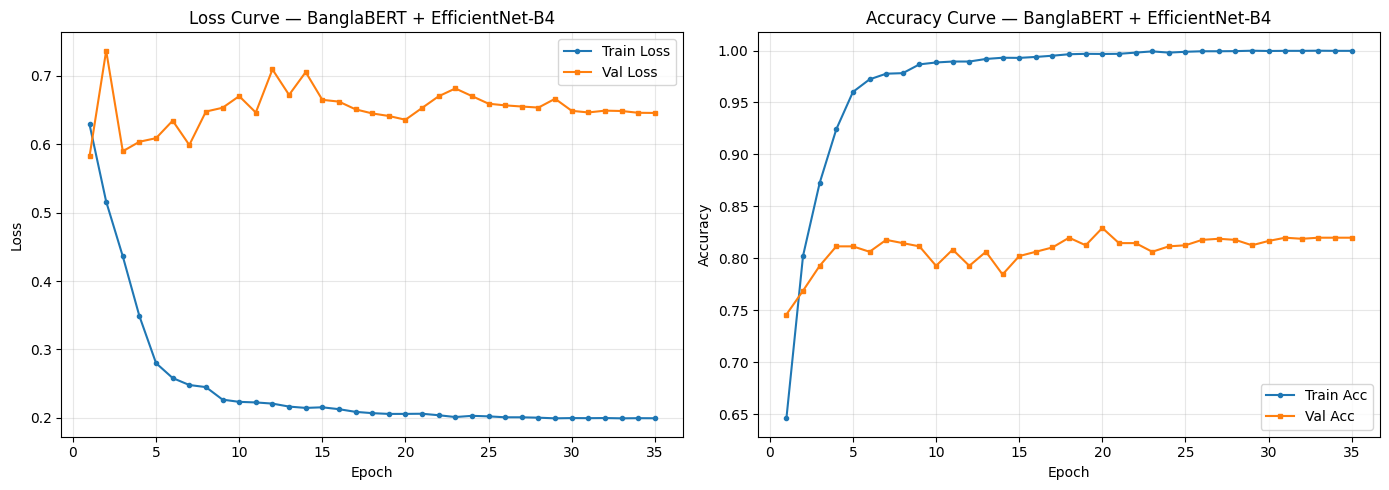

Training curves saved to Drive.


In [ ]:
metrics_path = os.path.join(LOG_DIR, 'metrics.json')
if os.path.exists(metrics_path):
    with open(metrics_path) as f:
        metrics = json.load(f)

epochs_ran = range(1, len(metrics['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_ran, metrics['train_loss'], label='Train Loss', marker='o', markersize=3)
axes[0].plot(epochs_ran, metrics['val_loss'],   label='Val Loss',   marker='s', markersize=3)
axes[0].set_title('Loss Curve — BanglaBERT + EfficientNet-B4')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_ran, metrics['train_acc'], label='Train Acc', marker='o', markersize=3)
axes[1].plot(epochs_ran, metrics['val_acc'],   label='Val Acc',   marker='s', markersize=3)
axes[1].set_title('Accuracy Curve — BanglaBERT + EfficientNet-B4')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(LOG_DIR, 'training_curves_b4.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Training curves saved to Drive.')


## STEP 15 — Load Best Model & Test Evaluation

In [ ]:
best_ckpt_path = os.path.join(CFG['checkpoint_dir'], 'best.pt')
print(f'Loading best checkpoint: {best_ckpt_path}')

best_ckpt = torch.load(best_ckpt_path, map_location=device, weights_only=True)
img_backbone.load_state_dict(best_ckpt['img_backbone'])
text_backbone.load_state_dict(best_ckpt['text_backbone'])
classifier.load_state_dict(best_ckpt['classifier'])
print(f'Best checkpoint was saved at epoch {best_ckpt["epoch"] + 1}')

img_backbone.eval()
text_backbone.eval()
classifier.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for images, input_ids, attn_mask, labels in tqdm(test_loader, desc='Testing'):
        images    = images.to(device)
        input_ids = input_ids.to(device)
        attn_mask = attn_mask.to(device)
        labels    = labels.view(-1)

        img_feats  = img_backbone(images)
        text_feats = text_backbone(input_ids, attn_mask)
        logits     = classifier(img_feats, text_feats)
        preds      = logits.argmax(dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)


Loading best checkpoint: /content/drive/MyDrive/MultiBanFake_BanglaBERT_EfficientNetB4/checkpoints/best.pt
Best checkpoint was saved at epoch 20


Testing: 100%|██████████| 160/160 [06:11<00:00,  2.32s/it]


## STEP 16 — Evaluation Metrics

In [ ]:
accuracy  = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
recall    = recall_score(all_labels, all_preds,    average='weighted', zero_division=0)
f1        = f1_score(all_labels, all_preds,        average='weighted', zero_division=0)
conf_mat  = confusion_matrix(all_labels, all_preds)

print('=' * 57)
print('  TEST RESULTS — BanglaBERT + EfficientNet-B4')
print('=' * 57)
print(f'  Accuracy  : {accuracy:.4f}  ({accuracy * 100:.2f}%)')
print(f'  Precision : {precision:.4f}')
print(f'  Recall    : {recall:.4f}')
print(f'  F1-Score  : {f1:.4f}')
print('=' * 57)
print()
print('Classification Report:')
print(classification_report(all_labels, all_preds, target_names=['Real (0)', 'Fake (1)']))

results = {
    'accuracy'   : float(accuracy),
    'precision'  : float(precision),
    'recall'     : float(recall),
    'f1_score'   : float(f1),
    'conf_matrix': conf_mat.tolist(),
}
with open(os.path.join(LOG_DIR, 'test_results_b4.json'), 'w') as f:
    json.dump(results, f, indent=2)
print('Test results saved to Drive.')


  TEST RESULTS — BanglaBERT + EfficientNet-B4
  Accuracy  : 0.8000  (80.00%)
  Precision : 0.8001
  Recall    : 0.8000
  F1-Score  : 0.8000

Classification Report:
              precision    recall  f1-score   support

    Real (0)       0.79      0.81      0.80       480
    Fake (1)       0.81      0.79      0.80       480

    accuracy                           0.80       960
   macro avg       0.80      0.80      0.80       960
weighted avg       0.80      0.80      0.80       960

Test results saved to Drive.


## STEP 17 — Confusion Matrix Plot

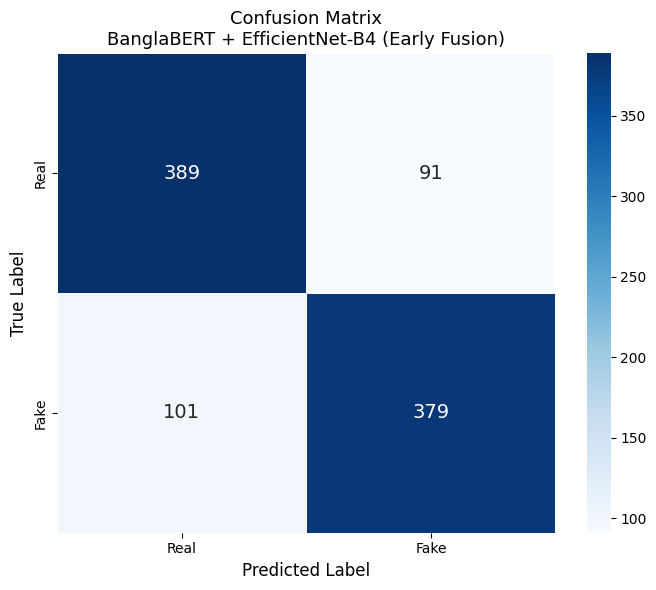

Confusion matrix saved to Drive.


In [ ]:
class_names = ['Real', 'Fake']

plt.figure(figsize=(7, 6))
sns.heatmap(
    conf_mat, annot=True, fmt='d', cmap='Blues',
    xticklabels=class_names, yticklabels=class_names,
    linewidths=0.5, annot_kws={'size': 14}
)
plt.title('Confusion Matrix\nBanglaBERT + EfficientNet-B4 (Early Fusion)', fontsize=13)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(LOG_DIR, 'confusion_matrix_b4.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Confusion matrix saved to Drive.')


## STEP 18 — Inference on a Single Sample

In [ ]:
def predict_single(image_path, description_text,
                   img_backbone, text_backbone, classifier,
                   tokenizer, transform, device):
    """
    Predict fake/real for one news item.
    Returns: (prediction_label, confidence_array)
    """
    img_backbone.eval(); text_backbone.eval(); classifier.eval()

    image = Image.open(image_path).convert('RGB')
    image = transform(image).unsqueeze(0).to(device)

    enc = tokenizer(
        description_text,
        padding        = 'max_length',
        truncation     = True,
        max_length     = CFG['max_seq_length'],
        return_tensors = 'pt',
    )
    input_ids = enc['input_ids'].to(device)
    attn_mask = enc['attention_mask'].to(device)

    with torch.no_grad():
        img_feats  = img_backbone(image)
        text_feats = text_backbone(input_ids, attn_mask)
        logits     = classifier(img_feats, text_feats)
        probs      = torch.softmax(logits, dim=1).squeeze().cpu().numpy()
        pred_label = int(np.argmax(probs))

    label_name = 'FAKE' if pred_label == 1 else 'REAL'
    print(f'Prediction  : {label_name} (label={pred_label})')
    print(f'Confidence  : Real={probs[0]:.4f} | Fake={probs[1]:.4f}')
    return pred_label, probs


# ─── Quick demo on first test sample ──────────────────────────────────────
sample = test_df.iloc[0]
print(f'Sample image : {sample["image_path"]}')
print(f'Description  : {str(sample["description"])[:120]}...')
print(f'True label   : {"FAKE" if sample["label"] == 1 else "REAL"}\n')

predict_single(
    image_path       = sample['image_path'],
    description_text = str(sample['description']),
    img_backbone     = img_backbone,
    text_backbone    = text_backbone,
    classifier       = classifier,
    tokenizer        = tokenizer,
    transform        = eval_transform,
    device           = device,
)


## STEP 19 — Reload Model in a New Session

In [ ]:
"""
Run this cell in a NEW Colab session to reload everything from Drive.
Uncomment all lines below and run.
"""

# from google.colab import drive
# drive.mount('/content/drive')
# import torch, timm, json, os, math
# import torch.nn as nn
# from transformers import AutoTokenizer, AutoModel
#
# DRIVE_BASE = '/content/drive/MyDrive/MultiBanFake_BanglaBERT_EfficientNetB4'
# MODEL_DIR  = os.path.join(DRIVE_BASE, 'saved_model')
# device     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#
# with open(os.path.join(MODEL_DIR, 'config.json')) as f:
#     CFG = json.load(f)
#
# # Rebuild architecture (copy class definitions from STEP 9)
# img_backbone  = EfficientNetBackbone(CFG['image_model_name'], pretrained=False).to(device)
# text_backbone = BanglaBERTBackbone(CFG['text_model_name']).to(device)
# classifier    = MultiFusionFake(img_backbone.out_dim, text_backbone.out_dim,
#                                  CFG['num_classes'], CFG['dropout']).to(device)
#
# img_backbone.load_state_dict(
#     torch.load(os.path.join(MODEL_DIR, 'img_backbone.pt'),  map_location=device, weights_only=True))
# text_backbone.load_state_dict(
#     torch.load(os.path.join(MODEL_DIR, 'text_backbone.pt'), map_location=device, weights_only=True))
# classifier.load_state_dict(
#     torch.load(os.path.join(MODEL_DIR, 'classifier.pt'),    map_location=device, weights_only=True))
#
# tokenizer = AutoTokenizer.from_pretrained(os.path.join(MODEL_DIR, 'tokenizer'))
# print('Model loaded from Drive successfully!')

print('Reload template ready — uncomment and run in a new session.')


---
## Summary of Changes: B3 → B4

| Component | B3 Notebook | **B4 Notebook (this file)** |
|-----------|-------------|------------------------------|
| Image model | `efficientnet_b3` | **`efficientnet_b4`** |
| Image resolution | 300×300 | **380×380** |
| Image feature dim | 1 536 | **1 792** |
| Fused dim | 2 304 | **2 560** |
| Batch size | 8 | **6** (B4 is heavier) |
| Augmentation | Flip + ColorJitter | **+ Crop, Rotation, Grayscale, GaussianBlur** |
| Classifier activation | ReLU | **GELU** |
| Normalisation | None | **LayerNorm on fused features** |
| Loss | CrossEntropy | **CrossEntropy + label smoothing 0.1** |
| Scheduler | CosineAnnealingLR | **Linear warmup + cosine decay (per-step)** |
| Dataset CSV names | `Val.csv` | **`Validation.csv`** |
| Dataset folder names | `train/test/validation` | **`Train/Test/Validation`** |
| Library versions | Fixed (Apr 2024) | **Latest stable (pip --upgrade)** |
| `weights_only=True` | Not set | **Set** (PyTorch ≥ 2.0 best practice) |

### Drive folder structure after training
```
MyDrive/MultiBanFake_BanglaBERT_EfficientNetB4/
    checkpoints/
        latest.pt
        best.pt
    saved_model/
        img_backbone.pt
        text_backbone.pt
        classifier.pt
        tokenizer/
        config.json
    logs/
        config.json
        metrics.json
        test_results_b4.json
        training_curves_b4.png
        confusion_matrix_b4.png
```
